### Plan-Execute 패턴

Plan-Execute 패턴은 복잡한 작업을 효율적으로 처리하기 위한 방법론이다. 이 패턴은 작업을 두 가지 주요 단계, 즉 **계획**(Plan)과 **실행**(Execute)으로 나누어 진행하는 것이 특징이다.

---

### 각 단계의 역할

-   **계획**(Plan) 단계는 사용자의 요청을 분석하고 목표 달성을 위한 구체적인 단계를 수립하는 것이다. 이 과정에서 어떤 정보를 검색하고 어떤 작업을 수행할지 미리 정한다.
-   **실행**(Execute) 단계는 수립된 계획의 각 단계를 순차적으로 수행하는 것이다. 각 단계의 결과는 다음 단계의 입력으로 사용되며, 모든 단계가 완료되면 최종 결과가 도출된다.

이 패턴은 각 단계의 역할이 명확하여, 복잡한 문제 해결 과정을 체계적이고 논리적으로 만드는 데 유용하다. 여러 도구를 순차적으로 사용해야 하는 경우에 특히 효과적인 방법이다.

In [6]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
  
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_web_search]

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

In [8]:
from langgraph.prebuilt import create_react_agent
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer in Korean.",
        ),
        ("human", "{messages}"),
    ]
)


# ReAct 에이전트 생성
agent_executor = create_react_agent(llm, tools, prompt=prompt)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9644\1342462114.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, tools, prompt=prompt)


In [9]:
query = "2026 월드컵에서 대한민국과 체코의 경기 결과는?"

In [10]:
from langchain_core.messages import HumanMessage

# 에이전트 실행
agent_executor.invoke(
    {"messages": [HumanMessage(content=query)]}
)


-------- WEB SEARCH --------
2026 월드컵 대한민국 체코 경기 일정 결과
m
1. snippet: [FIFA 월드컵 2026 프리뷰] 최종전에서 공동 개최국 멕시코 상대하는 체코., title: 대한민국 vs 체코 | 1차 예선 | FIFA 월드컵 2026™ | FIFA, link: https://www.fifa.com/ko/match-centre/match/17/285023/289273/400021441
2. snippet: 이번 글에서는 2026 월드컵 한국 일정, 한국 체코 경기 시간, 북중미 월드컵 중계, 월드컵 티켓 예매 방법까지 한 번에 정리하겠습니다.2026 북중미 월드컵 대한민국 조별리그 일정은 다음과 같습니다., title: 2026 월드컵 한국 일정 북중미 월드컵 한국 체코 경기 시간·중계·티켓..., link: https://contents.premium.naver.com/gobaksa/imyeonnews/contents/260605214600932sq
3. snippet: 2026 FIFA 월드컵 조별리그 A조에 대해 서술한 문서. 일정 6경기 중 4경기가 고지대 경기장이 위치한 멕., title: 2026 FIFA 월드컵/A조 - 나무위키, link: https://namu.wiki/w/2026+FIFA+월드컵/A조
4. snippet: 대한민국 축구 국가대표팀이 배정된 2026 FIFA 월드컵 A조에는 체코(FIFA 36위), 멕시코(FIFA 12위), 남아프리카공화국(FIFA 60위)이 함께 배정됐다., title: 2026 월드컵 한국 A조 최종 점검 — 체코·멕시코·남아공 완전..., link: https://worldcup.overthetop.co.kr/2026-월드컵-한국-a조-최종-점검-체코-멕시코-남아공/


{'messages': [HumanMessage(content='2026 월드컵에서 대한민국과 체코의 경기 결과는?', additional_kwargs={}, response_metadata={}, id='0a825479-4bd9-464e-9c6b-0213cd585e25'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_web_search', 'arguments': '{"query": "2026 \\uc6d4\\ub4dc\\ucef5 \\ub300\\ud55c\\ubbfc\\uad6d \\uccb4\\ucf54 \\uacbd\\uae30 \\uc77c\\uc815 \\uacb0\\uacfc"}'}, '__gemini_function_call_thought_signatures__': {'6e0e6b05-2f7e-42d8-8e27-27449f2d553b': 'EjQKMgEMOdbHwbyfXR0iUxqiAUcjlS5/4EiFcyG5uRmUWFjbXocN1fMGwE13eYaOLcibtrq3'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebdce-b2c0-7c80-9ee4-129eadcc2577-0', tool_calls=[{'name': 'get_web_search', 'args': {'query': '2026 월드컵 대한민국 체코 경기 일정 결과'}, 'id': '6e0e6b05-2f7e-42d8-8e27-27449f2d553b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 135, 'output_tokens': 30, 'total_tokens': 

In [11]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


# 상태 정의
class PlanExecute(TypedDict):
    input: Annotated[str, "User's input"]
    plan: Annotated[List[str], "Current plan"]
    past_steps: Annotated[List[Tuple], operator.add]
    response: Annotated[str, "Final response"]

In [12]:
from pydantic import BaseModel, Field
from typing import List


# Plan 모델 정의
class Plan(BaseModel):
    """Sorted steps to execute the plan"""

    steps: Annotated[List[str], "Different steps to follow, should be in sorted order"]

In [13]:
from langchain_core.prompts import ChatPromptTemplate

# 계획 수립을 위한 프롬프트 템플릿 생성
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """주어진 목표에 대해 간단한 단계별 계획을 세워주세요. \
이 계획은 정확한 답을 도출하는 데 필요한 개별적인 작업들로 구성되어야 합니다. \
불필요한 단계는 추가하지 마세요. 마지막 단계의 결과가 최종 답변이어야 합니다. \
각 단계에 필요한 모든 정보가 포함되어 있는지 확인하고, 단계를 건너뛰지 마세요.
답변은 한글로 작성하세요.""",
        ),
        ("placeholder", "{messages}"),
    ]
)

planner = planner_prompt | ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0).with_structured_output(Plan)

In [15]:
from langchain.messages import HumanMessage

# Planner 실행
planner.invoke(
    {
        "messages": [
            HumanMessage(content=query)
        ]
    }
)

Plan(steps=['2026년 FIFA 월드컵의 개최 기간 및 현재 진행 상황을 확인합니다.', '대한민국과 체코의 2026년 월드컵 본선 진출 여부 및 조 편성 결과를 확인합니다.', '두 국가 간의 맞대결 일정이 있는지 확인하고, 해당 대회가 아직 개최되지 않은 미래의 이벤트이므로 현재로서는 실제 경기 결과를 알 수 없음을 최종 답변으로 도출합니다.'])

In [16]:
from typing import Literal
from pydantic import BaseModel, Field

# 사용자 응답
class Response(BaseModel):
    """Response to user."""
    # 사용자 응답
    response: str = Field(description="The final response to the user.")

# 계획 재수립
class Plan(BaseModel):
    """Action to perform."""
    # 수행할 작업: "Response", "Plan".
    steps: list[str] = Field(description="List of steps to be performed.")


# 계획을 재수립하기 위한 프롬프트 정의
replanner_prompt = ChatPromptTemplate.from_template(
    """주어진 목표에 대해 간단한 단계별 계획을 세워주세요. \
이 계획은 정확한 답을 도출하는 데 필요한 개별적인 작업들로 구성되어야 합니다. \
불필요한 단계는 추가하지 마세요. 마지막 단계의 결과가 최종 답변이어야 합니다. \
각 단계에 필요한 모든 정보가 포함되어 있는지 확인하고, 단계를 건너뛰지 마세요.

당신의 목표는 다음과 같습니다:
{input}

당신의 원래 계획은 다음과 같습니다:
{plan}

당신이 현재까지 완료한 단계는 다음과 같습니다:
{past_steps}

계획을 적절하게 업데이트하세요. 더 이상 필요한 단계가 없고 사용자에게 답변을 반환할 수 있다면, 그것으로 응답하세요. \
그렇지 않다면, 계획을 다시 작성하세요. 아직 완료되지 않은 단계만 계획에 추가하세요. \
이전에 완료한 단계를 계획에 다시 포함시키지 마세요.

답변은 한글로 작성하세요."""
)


# Replanner 생성
replanner = replanner_prompt | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0).bind_tools(
    tools=[Response, Plan],
    # tool_choice=Literal["Response", "Plan"]
)

In [17]:
from langchain_core.output_parsers import StrOutputParser


# 사용자 입력을 기반으로 계획을 생성하고 반환
def plan_step(state: PlanExecute):
    plan = planner.invoke({"messages": [("user", state["input"])]})
    # 생성된 계획의 단계 리스트 반환
    return {"plan": plan.steps}


# 에이전트 실행기를 사용하여 주어진 작업을 수행하고 결과를 반환
def execute_step(state: PlanExecute):
    plan = state["plan"]
    # 계획을 문자열로 변환하여 각 단계에 번호를 매김
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    # 현재 실행할 작업을 포맷팅하여 에이전트에 전달
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing [step 1. {task}]."""
    # 에이전트 실행기를 통해 작업 수행 및 결과 수신
    agent_response = agent_executor.invoke({"messages": [("user", task_formatted)]})
    # 이전 단계와 그 결과를 포함하는 딕셔너리 반환
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


# 이전 단계의 결과를 바탕으로 계획을 업데이트하거나 최종 응답을 반환
def replan_step(state: PlanExecute):
    output = replanner.invoke(state)

    # 모델이 도구 호출을 생성했는지 확인
    if output.tool_calls:
        tool_call = output.tool_calls[0]
        tool_name = tool_call['name']
        tool_args = tool_call['args']

        # 도구 이름에 따라 분기
        if tool_name == 'Response':
            return {"response": tool_args.get('response')}
        elif tool_name == 'Plan':
            return {"plan": tool_args.get('steps')}
    
    # 도구 호출이 없는 경우 (일반적인 메시지)
    return {"response": output.content}


# 에이전트의 실행 종료 여부를 결정하는 함수
def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return "final_report"
    else:
        return "execute"


final_report_prompt = ChatPromptTemplate.from_template(
    """당신에게는 목표와 이전에 완료된 단계들이 주어졌습니다. 당신의 임무는 마크다운 형식으로 최종 보고서를 생성하는 것입니다.
최종 보고서는 전문적인 어조로 작성되어야 합니다.

당신의 목표는 다음과 같습니다:

{input}

이전에 완료된 단계들(질문과 답변 쌍):

{past_steps}

마크다운 형식으로 최종 보고서를 생성하세요. 답변은 한글로 작성하세요."""
)

final_report = (
    final_report_prompt
    | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
    | StrOutputParser()
)


def generate_final_report(state: PlanExecute):
    past_steps = "\n\n".join(
        [
            f"Question: {past_step[0]}\n\nAnswer: {past_step[1]}\n\n####"
            for past_step in state["past_steps"]
        ]
    )
    response = final_report.invoke({"input": state["input"], "past_steps": past_steps})
    return {"response": response}

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


# 그래프 생성
workflow = StateGraph(PlanExecute)

# 노드 정의
workflow.add_node("planner", plan_step)
workflow.add_node("execute", execute_step)
workflow.add_node("replan", replan_step)
workflow.add_node("final_report", generate_final_report)

# 엣지 정의
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "execute")
workflow.add_edge("execute", "replan")
workflow.add_edge("final_report", END)

# 조건부 엣지: replan 후 종료 여부를 결정하는 함수 사용
workflow.add_conditional_edges(
    "replan",
    should_end,
    {"execute": "execute", "final_report": "final_report"},
)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

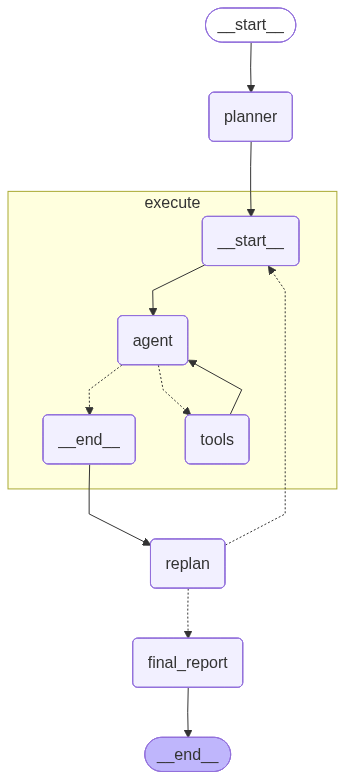

In [20]:
from IPython.display import Image

Image(app.get_graph(xray=True).draw_mermaid_png())

In [21]:
import uuid

# 에이전트 실행
result = app.invoke(
    {"input": query},
    config={"configurable": {"thread_id": str(uuid.uuid4())}}
)

# 결과 출력
print(result)


-------- WEB SEARCH --------
2026년 FIFA 월드컵 개최 기간 및 현재 진행 상황
m
1. snippet: 21 hours ago · The 2026 FIFA World Cup is the current and 23rd edition of the FIFA World Cup, the quadrennial international men's soccer championship contested by the national teams of the member associations of FIFA., title: 2026 FIFA World Cup - Wikipedia, link: https://en.wikipedia.org/wiki/2026_FIFA_World_Cup
2. snippet: May 20, 2026 · 2026 북중미 월드컵이 드디어 시작됩니다.이번 대회는 사상 최초로 미국·캐나다·멕시코 3개국 공동 개최이며, 참가국도 48개국으로 확대됐습니다.특히 대한민국 축구대표팀 경기 시간이 한국 팬들에게 매우 좋은 시간대로 배정되면서 기대감이 커지고 있습니다 ..., title: 2026 북중미 월드컵 전체 경기 일정 및 대한민국 대표팀 시간표 총정..., link: https://the-gee.tistory.com/entry/2026-북중미-월드컵-전체-경기-일정-및-대한민국-대표팀-시간표-총정리
3. snippet: Jun 5, 2026 · 2026 월드컵 기본 정보 대회명: 2026 FIFA World Cup 개최국: United States · Mexico · Canada 공동 개최 개최 기간: 2026년 6월 11일 ~ 7월 예정 참가국: 48개국 총 경기 수: 104경기 이번 월드컵은 기존 32개국 체제에서 확대되면서 조별리그 경기 수도 크게 늘었습니다., title: 2026 월드컵 한국 경기 일정 총정리대한민국 첫 경기 시간·상대·조별..., link: https://m.blog.naver.com/ho2026k/2242

In [22]:
import pprint

pprint.pprint(result)

{'input': '2026 월드컵에서 대한민국과 체코의 경기 결과는?',
 'past_steps': [('2026년 FIFA 월드컵의 개최 기간 및 현재 진행 상황을 확인합니다.',
                 [{'extras': {'signature': 'EjQKMgEMOdbHtT/bmMt/aN8WGsnv8v47/AytZhmA+DOum7Yp8ZmFnVRhUaxC1ywM6l1mVJjj'},
                   'text': '2026년 FIFA 월드컵에 대한 1단계 확인 결과는 다음과 같습니다.\n'
                           '\n'
                           '*   **개최 기간:** 2026년 6월 11일부터 7월까지 진행됩니다.\n'
                           '*   **개최국:** 미국, 캐나다, 멕시코 3개국이 공동 개최합니다.\n'
                           '*   **현재 진행 상황:** 2026년 6월을 기준으로 대회가 시작되어 진행 중인 '
                           '상태입니다. 이번 대회는 사상 최초로 48개국이 참가하며 총 104경기가 치러집니다.\n'
                           '\n'
                           "이제 다음 단계인 '대한민국과 체코의 2026년 월드컵 본선 진출 여부 및 조 편성 결과 "
                           "확인'을 진행하겠습니다.",
                   'type': 'text'}]),
                ('대한민국과 체코의 2026년 월드컵 본선 진출 여부 및 조 편성 결과를 확인합니다.',
                 [{'extras': {'signature': 'EjQKMgEMOdbHgalyDCKyKRuKiwb3/5ck5sUdBbZDOSi8DY/15qdJlYIMcIfIcxcSh3o